<a href="https://colab.research.google.com/github/PisaFig/CMPE-138-Proj/blob/main/CMPE_138_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade google-cloud-bigquery


In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery


project_id = "lyrical-lyceum-456416-j7"
client = bigquery.Client(project=project_id)

print("Using project:", client.project)


Using project: lyrical-lyceum-456416-j7


In [ ]:
#PM2.5 Vs Humidity

In [ ]:
# Demo: Main query combining EPA PM2.5 data with NOAA temperature/dewpoint data
# Optimized using CTEs (WITH clauses) for step-by-step processing and better performance
query_filtered_epa = """
-- Step 1:Filter and preprocess NOAA weather data by selecting daily temperature and dewpoint values from 2018 to 2025,
--and convert them from Fahrenheit to Celsius for later use.
WITH filtered_noaa AS (
  SELECT
    stn,
    wban,
    year,
    mo,
    da,
    temp,
    dewp,
    -- Precompute Celsius conversion in the WITH clause for efficiency
    (temp - 32) * 5 / 9 AS temp_celsius,
    (dewp - 32) * 5 / 9 AS dewp_celsius
  FROM `bigquery-public-data.noaa_gsod.gsod*`
  WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64))
        BETWEEN '2018-01-01' AND '2025-12-31'
),

-- Step 2: Identify NOAA weather stations in the San Jose area
san_jose_stations AS (
  SELECT usaf, wban, name
  FROM `bigquery-public-data.noaa_gsod.stations`
  WHERE state = 'CA' AND name LIKE 'SAN JOSE%'
),

-- Step 3: Filter EPA PM2.5 data for Santa Clara County on the 1st day of each month
filtered_epa AS (
  SELECT
    date_local,
    arithmetic_mean
  FROM `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary`
  WHERE state_name = 'California'
    AND county_name LIKE 'Santa Clara'
    AND EXTRACT(DAY FROM date_local) = 1
    AND date_local BETWEEN '2018-01-01' AND '2025-12-31'
)

-- Step 4: Join filtered EPA and NOAA data, calculate relative humidity
SELECT
  e.date_local AS date,
  e.arithmetic_mean AS pm25,
  n.dewp AS dewpoint,
  n.temp,
  -- Using precomputed Celsius values from the WITH clause to calculate humidity
  ROUND(
    100 *
    EXP(17.625 * n.dewp_celsius / (n.dewp_celsius + 243.04)) /
    EXP(17.625 * n.temp_celsius / (n.temp_celsius + 243.04)),
  2) AS humidity,
  s.name AS station_name

FROM filtered_epa e
LEFT JOIN filtered_noaa n
  ON e.date_local = DATE(CAST(n.year AS INT64), CAST(n.mo AS INT64), CAST(n.da AS INT64))
LEFT JOIN san_jose_stations s
  ON CAST(n.stn AS STRING) = s.usaf AND n.wban = s.wban

ORDER BY e.date_local ASC

"""
job_epa = client.query(query_filtered_epa)
results_epa = job_epa.result()

df_epa = results_epa.to_dataframe()
print(df_epa)

               date  pm25  dewpoint  temp      humidity station_name
0        2018-01-01  45.0      63.2  65.5  9.228000e+01         None
1        2018-01-01  45.0    9999.9  55.6  8.726345e+08         None
2        2018-01-01  45.0      24.9  25.6  9.713000e+01         None
3        2018-01-01  45.0       6.1   8.5  8.971000e+01         None
4        2018-01-01  45.0     -40.6 -35.2  7.348000e+01         None
...             ...   ...       ...   ...           ...          ...
3679352  2024-02-01   3.0    9999.9  34.7  1.930516e+09         None
3679353  2024-02-01   3.0    9999.9  49.7  1.083856e+09         None
3679354  2024-02-01   3.0    9999.9  41.8  1.461881e+09         None
3679355  2024-02-01   3.0    9999.9  17.3  3.969851e+09         None
3679356  2024-02-01   3.0    9999.9  51.9  9.990448e+08         None

[3679357 rows x 6 columns]


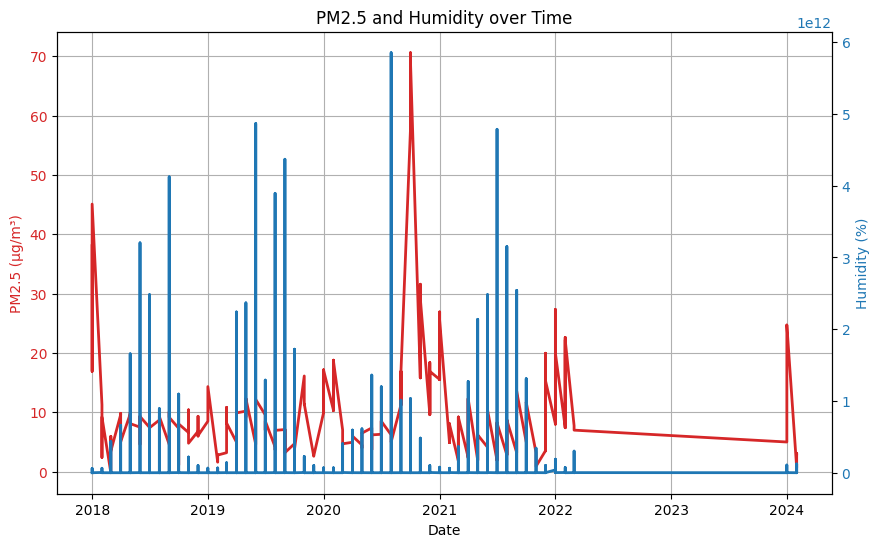

In [ ]:
import matplotlib.pyplot as plt

# Query execution (you already have this part)
job_epa = client.query(query_filtered_epa)
results_epa = job_epa.result()

# Convert the results to a DataFrame
df_epa = results_epa.to_dataframe()

# Create the figure and axis for the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot PM2.5 on the primary y-axis (left)
ax1.plot(df_epa['date'], df_epa['pm25'], color='tab:red', label='PM2.5', linewidth=2)
ax1.set_xlabel('Date')
ax1.set_ylabel('PM2.5 (µg/m³)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')

# Create a secondary y-axis for humidity
ax2 = ax1.twinx()
ax2.plot(df_epa['date'], df_epa['humidity'], color='tab:blue', label='Humidity', linewidth=2)
ax2.set_ylabel('Humidity (%)', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# Title and grid
plt.title('PM2.5 and Humidity over Time')
ax1.grid(True)

# Show the plot
plt.show()


In [ ]:
# Pearson's correlation measures the strength and direction of the linear relationship
# between two variables. It's calculated based on the covariance of the variables
# and the standard deviations of each variable.
plt.show()

# Calculate Pearson correlation using the same DataFrame
correlation = df_epa['pm25'].corr(df_epa['humidity'])
print(f"Pearson correlation between PM2.5 and Humidity: {correlation:.3f}")


Pearson correlation between PM2.5 and Humidity: -0.003


In [ ]:
#NO2 vs Temp

                date  NO2_concentration  temp  prcp city_name wind_speed  \
0         2018-01-01          23.165217 -20.5  0.00  San Jose      999.9   
1         2018-01-01          23.165217  36.4  0.04  San Jose        7.1   
2         2018-01-01          23.165217  30.3  0.00  San Jose        7.8   
3         2018-01-01          23.165217  53.2  0.00  San Jose        2.1   
4         2018-01-01          23.165217  71.0  0.00  San Jose       10.5   
...              ...                ...   ...   ...       ...        ...   
34631211  2024-01-01          13.469565  74.6  0.00  San Jose        3.0   
34631212  2024-01-01          13.469565  25.5  0.00  San Jose        8.6   
34631213  2024-01-01          13.469565  23.2  0.00  San Jose        7.0   
34631214  2024-01-01          13.469565  90.5  0.00  San Jose        9.3   
34631215  2024-01-01          13.469565  83.6  0.00  San Jose        4.8   

          county_name  
0         Santa Clara  
1         Santa Clara  
2         Santa

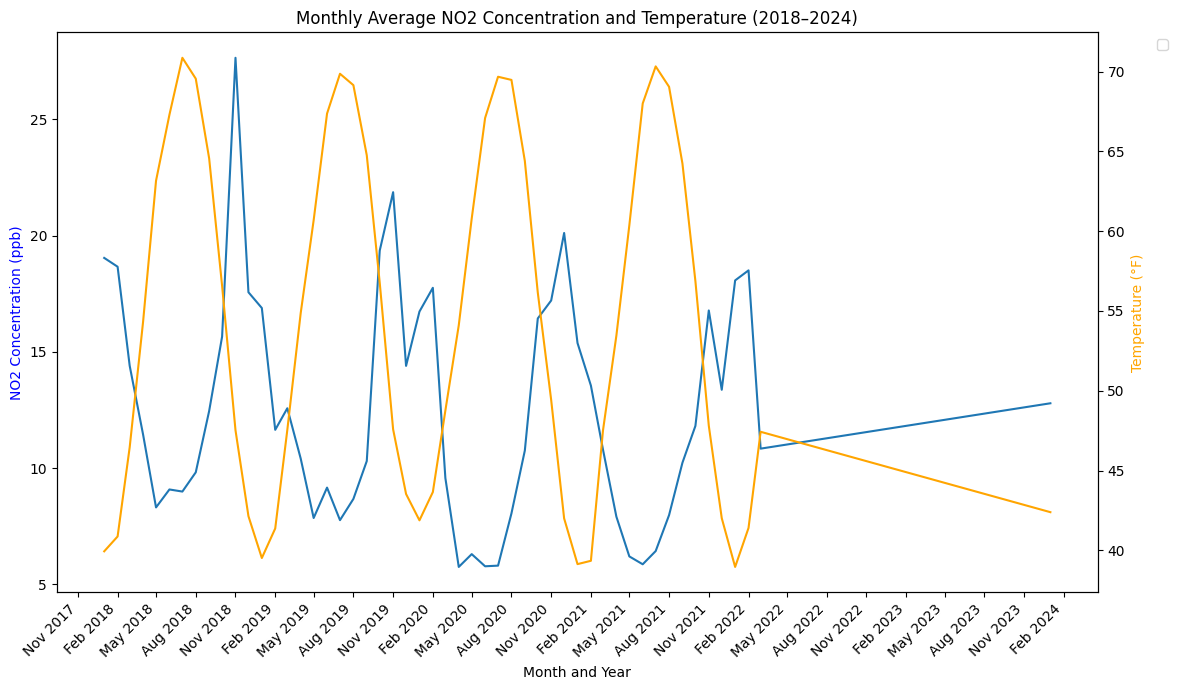

Pearson correlation between NO2 concentration and temperature: -0.697


In [ ]:
query_ahmed2_medOptimal = """
WITH weather_data AS (
  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2018`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2019`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2020`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2021`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2022`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2023`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2024`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'
)


SELECT
  t1.date_local AS date,
  t1.arithmetic_mean AS NO2_concentration,
  t2.temp,
  t2.prcp, t1.city_name,
  t2.wdsp AS wind_speed,
  t1.county_name,
FROM
  `bigquery-public-data.epa_historical_air_quality.no2_daily_summary` AS t1
LEFT JOIN weather_data AS t2
ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))
WHERE
  t1.state_name = 'California'
  AND t1.county_name LIKE 'Santa Clara'
  AND t1.date_local BETWEEN '2018-01-01' AND '2024-01-01'
ORDER BY
  date ASC;
"""
query_optimized=  """
WITH weather_data AS (
  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod*`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'
)


SELECT
  t1.date_local AS date,
  t1.arithmetic_mean AS NO2_concentration,
  t2.temp,
  t2.prcp, t1.city_name,
  t2.wdsp AS wind_speed,
  t1.county_name,
FROM
  `bigquery-public-data.epa_historical_air_quality.no2_daily_summary` AS t1
LEFT JOIN weather_data AS t2
ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))
WHERE
  t1.state_name = 'California'
  AND t1.county_name LIKE 'Santa Clara'
  AND t1.date_local BETWEEN '2018-01-01' AND '2024-01-01' AND t1.city_name = 'San Jose'
ORDER BY
  date ASC;
"""
query_ahmed2_unoptimized="""
                        SELECT
                          t1.date_local AS date,
                          t1.arithmetic_mean AS NO2_concentration,
                          t2.temp,
                          t2.prcp,
                          t1.city_name,
                          t2.wdsp AS wind_speed,
                          t1.county_name,
                          s.name AS station_name
                        FROM
                          `bigquery-public-data.epa_historical_air_quality.no2_daily_summary` AS t1
                        LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2018` AS t2
                        ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))

                        LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2019` AS t3
                        ON t1.date_local = DATE(CAST(t3.year AS INT64), CAST(t3.mo AS INT64), CAST(t3.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2020` AS t4
                        ON t1.date_local = DATE(CAST(t4.year AS INT64), CAST(t4.mo AS INT64), CAST(t4.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2021` AS t5
                        ON t1.date_local = DATE(CAST(t5.year AS INT64), CAST(t5.mo AS INT64), CAST(t5.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2022` AS t6
                        ON t1.date_local = DATE(CAST(t6.year AS INT64), CAST(t6.mo AS INT64), CAST(t6.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2023` AS t7
                        ON t1.date_local = DATE(CAST(t7.year AS INT64), CAST(t7.mo AS INT64), CAST(t7.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2024` AS t8
                        ON t1.date_local = DATE(CAST(t8.year AS INT64), CAST(t8.mo AS INT64), CAST(t8.da AS INT64))


                        LEFT JOIN
                          `bigquery-public-data.noaa_gsod.stations` AS s
                        ON
                          t2.stn = s.usaf AND t2.wban = s.wban AND  t3.stn = s.usaf AND t3.wban = s.wban AND  t4.stn = s.usaf AND t4.wban = s.wban AND  t5.stn = s.usaf AND t5.wban = s.wban AND  t6.stn = s.usaf AND t6.wban = s.wban AND  t7.stn = s.usaf AND t7.wban = s.wban AND  t8.stn = s.usaf AND t8.wban = s.wban
                          AND s.state = 'CA'
                          AND s.name LIKE 'SAN JOSE%'
                        WHERE
                          t1.state_name = 'California'
                          AND t1.county_name LIKE 'Santa Clara'
                          AND t1.date_local BETWEEN '2018-01-01' AND '2024-01-01'
                        ORDER BY
                          date ASC;


"""
query_job = client.query(query_optimized)
results1 = query_job.result().to_dataframe()

print(results1)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.dates as mdates

# Ensure 'date' column is datetime
results1['date'] = pd.to_datetime(results1['date'])

# Extract month for grouping
results1['month'] = results1['date'].dt.to_period('M')

# Group by month and compute averages
monthly_avg = results1.groupby('month').agg({
    'NO2_concentration': 'mean',
    'temp': 'mean'
}).reset_index()

# Convert Period to datetime for plotting
monthly_avg['month'] = monthly_avg['month'].dt.to_timestamp()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(14, 7))

# Set x-axis formatting BEFORE plotting
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Plot NO2 on left y-axis
sns.lineplot(data=monthly_avg, x='month', y='NO2_concentration', ax=ax1)
ax1.set_xlabel('Month and Year')
ax1.set_ylabel('NO2 Concentration (ppb)', color='blue')

# Create right y-axis and plot temperature
ax2 = ax1.twinx()
sns.lineplot(data=monthly_avg, x='month', y='temp', ax=ax2, color='orange')
ax2.set_ylabel('Temperature (°F)', color='orange')

# Improve x-axis tick visibility
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.05, 1), loc='upper left')

# Title and layout
plt.title('Monthly Average NO2 Concentration and Temperature (2018–2024)')
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make space for legend

plt.show()

# Calculate and print Pearson correlation
correlation = monthly_avg['NO2_concentration'].corr(monthly_avg['temp'])
print(f"Pearson correlation between NO2 concentration and temperature: {correlation:.3f}")


In [ ]:
# Optimized
query = """
WITH
ozone_with_rownum AS (
  SELECT
    state_code AS state,
    county_name AS county,
    site_num,
    date_local,
    arithmetic_mean AS o3_mean,
    ROW_NUMBER() OVER (PARTITION BY county_name, date_local ORDER BY site_num) AS row_num
  FROM
    `bigquery-public-data.epa_historical_air_quality.o3_daily_summary`
  WHERE
    state_name = 'California'
    AND date_local BETWEEN '2018-01-01' AND '2025-01-07'
),
noaa_temp AS (
  SELECT
    DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) AS date_local,
    AVG(temp) AS avg_temp
  FROM (
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2018`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2019`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2020`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2021`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2022`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2023`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2024`
    UNION ALL
    SELECT year, mo, da, temp
    FROM `bigquery-public-data.noaa_gsod.gsod2025`)
  WHERE temp IS NOT NULL
  GROUP BY date_local
)
SELECT
  o.state,
  o.county,
  o.site_num,
  o.date_local,
  o.o3_mean,
  n.avg_temp
FROM
  ozone_with_rownum o
LEFT JOIN
  noaa_temp n
ON
  o.date_local = n.date_local
WHERE
  o.row_num = 1
"""
df = client.query(query).result().to_dataframe()
# Print the entire DataFrame
print(df)

# preview
print(df.head())

      state   county site_num  date_local   o3_mean   avg_temp
0        06  Alameda     0007  2019-01-23  0.011529  39.360049
1        06  Alameda     0007  2019-09-13  0.042765  65.426697
2        06  Alameda     0007  2019-11-12  0.025588  46.039680
3        06  Alameda     0007  2019-12-08  0.014000  44.576840
4        06  Alameda     0007  2020-02-04  0.019294  42.654959
...     ...      ...      ...         ...       ...        ...
78290    06     Yolo     0004  2020-10-09  0.021706  59.452488
78291    06     Yolo     0004  2020-12-24  0.007176  41.578978
78292    06     Yolo     0004  2021-07-15  0.024294  70.591041
78293    06     Yolo     0004  2021-08-22  0.033118  68.529324
78294    06     Yolo     0004  2021-09-16  0.027471  64.481924

[78295 rows x 6 columns]
  state   county site_num  date_local   o3_mean   avg_temp
0    06  Alameda     0007  2019-01-23  0.011529  39.360049
1    06  Alameda     0007  2019-09-13  0.042765  65.426697
2    06  Alameda     0007  2019-11-12  0.

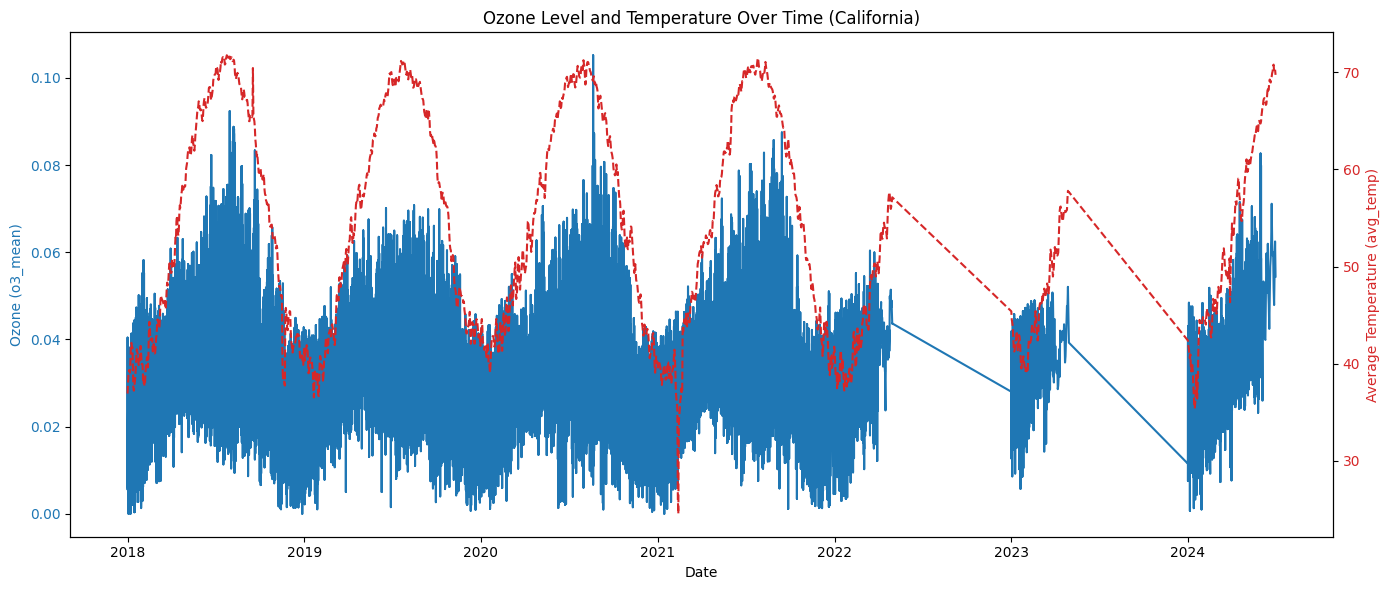

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume your query result is already loaded into a DataFrame `df`
# Columns: 'state', 'county', 'site_num', 'date_local', 'o3_mean', 'avg_temp'

# Make sure date_local is datetime type
df['date_local'] = pd.to_datetime(df['date_local'])

# Sort by date just to be safe
df = df.sort_values('date_local')

# Plot Ozone and Temp over time
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Ozone on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Ozone (o3_mean)', color=color)
ax1.plot(df['date_local'], df['o3_mean'], color=color, label='Ozone Mean (o3_mean)')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for Temperature
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Temperature (avg_temp)', color=color)
ax2.plot(df['date_local'], df['avg_temp'], color=color, linestyle='--', label='Average Temperature (avg_temp)')
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout
plt.title('Ozone Level and Temperature Over Time (California)')
fig.tight_layout()

# Show plot
plt.show()

In [ ]:
plt.show()

# Calculate Pearson correlation using the same DataFrame
# 'Ozone' to 'o3_mean' and 'Temperature' to 'avg_temp'
correlation = df['o3_mean'].corr(df['avg_temp'])
print(f"Pearson correlation between Ozone (o3_mean) and Temperature (avg_temp): {correlation:.3f}")

Pearson correlation between Ozone (o3_mean) and Temperature (avg_temp): 0.435
